# Requirements

## Packages

In [ ]:
!pip install imagecodecs

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 26.5/26.5 MB 59.9 MB/s eta 0:00:00


## Functions

In [ ]:
def show_random_image(seed):
    import os
    import glob
    import random
    import re
    import tifffile as tiff
    import matplotlib.pyplot as plt
    import numpy as np

    base_dir = "data"
    rng = random.Random(seed)

    image_paths = []

    for tif_path in sorted(glob.glob(os.path.join(base_dir, "**", "*.tif"), recursive=True)):
        norm_path = os.path.normpath(tif_path)
        parts = norm_path.split(os.sep)

        filename = parts[-1]
        parent_dir = parts[-2] if len(parts) >= 2 else ""

        if not re.fullmatch(r"t\d+\.tif", filename):
            continue
        if not re.fullmatch(r"\d{2}", parent_dir):
            continue

        # Exclude annotation folders anywhere in the path
        bad_part = False
        for p in parts:
            if p.endswith("_GT") or p.endswith("_ST") or p.endswith("_ERR_SEG") or p in {"GT", "SEG", "TRA"}:
                bad_part = True
                break
        if bad_part:
            continue

        dataset_container = parts[1] if len(parts) > 1 else "unknown"

        # dataset_name = folder before sequence unless that would be "data"
        dataset_name = parts[-3] if len(parts) >= 3 else dataset_container
        if dataset_name == dataset_container and len(parts) >= 4:
            dataset_name = parts[-3]

        image_paths.append((dataset_container, dataset_name, tif_path))

    unique_datasets = sorted(set((c, d) for c, d, _ in image_paths))
    print(f"Found {len(image_paths)} raw image frames across {len(unique_datasets)} datasets.")

    if not image_paths:
        raise ValueError("No raw .tif image frames found. Check your extracted folder structure.")

    dataset_container, dataset_name, chosen_path = rng.choice(image_paths)
    img = tiff.imread(chosen_path)

    parts = os.path.normpath(chosen_path).split(os.sep)
    sequence = parts[-2]
    filename = parts[-1]

    print(f"Seed: {seed}")
    print(f"Dataset container: {dataset_container}")
    print(f"Dataset name: {dataset_name}")
    print(f"Sequence: {sequence}")
    print(f"Frame: {filename}")
    print(f"Shape: {img.shape}")
    print(f"Dtype: {img.dtype}")
    print(f"Min: {img.min()}")
    print(f"Max: {img.max()}")
    print(f"Mean: {img.mean():.2f}")
    print(f"Std: {img.std():.2f}")

    plt.figure(figsize=(6, 6))
    plt.imshow(img, cmap="gray")
    plt.title(f"{dataset_name} | {sequence}/{filename}")
    plt.axis("off")
    plt.show()

# Import Dataset

Dataset page https://celltrackingchallenge.net/2d-datasets/

In [ ]:
import os

In [ ]:
# Create a directory to store datasets
os.makedirs("data", exist_ok=True)

In [ ]:
datasets = {
    # --- BF (Brightfield) ---
    "BF-C2DL-HSC_train": "https://data.celltrackingchallenge.net/training-datasets/BF-C2DL-HSC.zip",
    "BF-C2DL-HSC_test":  "https://data.celltrackingchallenge.net/test-datasets/BF-C2DL-HSC.zip",

    "BF-C2DL-MuSC_train": "https://data.celltrackingchallenge.net/training-datasets/BF-C2DL-MuSC.zip",
    "BF-C2DL-MuSC_test":  "https://data.celltrackingchallenge.net/test-datasets/BF-C2DL-MuSC.zip",

    # --- DIC ---
    "DIC-C2DH-HeLa_train": "https://data.celltrackingchallenge.net/training-datasets/DIC-C2DH-HeLa.zip",
    "DIC-C2DH-HeLa_test":  "https://data.celltrackingchallenge.net/test-datasets/DIC-C2DH-HeLa.zip",

    # --- Fluorescence (2D + time) ---
    "Fluo-C2DL-Huh7_train": "https://data.celltrackingchallenge.net/training-datasets/Fluo-C2DL-Huh7.zip",
    "Fluo-C2DL-Huh7_test":  "https://data.celltrackingchallenge.net/test-datasets/Fluo-C2DL-Huh7.zip",

    "Fluo-C2DL-MSC_train": "https://data.celltrackingchallenge.net/training-datasets/Fluo-C2DL-MSC.zip",
    "Fluo-C2DL-MSC_test":  "https://data.celltrackingchallenge.net/test-datasets/Fluo-C2DL-MSC.zip",

    "Fluo-N2DH-GOWT1_train": "https://data.celltrackingchallenge.net/training-datasets/Fluo-N2DH-GOWT1.zip",
    "Fluo-N2DH-GOWT1_test":  "https://data.celltrackingchallenge.net/test-datasets/Fluo-N2DH-GOWT1.zip",

    "Fluo-N2DL-HeLa_train": "https://data.celltrackingchallenge.net/training-datasets/Fluo-N2DL-HeLa.zip",
    "Fluo-N2DL-HeLa_test":  "https://data.celltrackingchallenge.net/test-datasets/Fluo-N2DL-HeLa.zip",

    # --- Phase Contrast ---
    "PhC-C2DH-U373_train": "https://data.celltrackingchallenge.net/training-datasets/PhC-C2DH-U373.zip",
    "PhC-C2DH-U373_test":  "https://data.celltrackingchallenge.net/test-datasets/PhC-C2DH-U373.zip",

    "PhC-C2DL-PSC_train": "https://data.celltrackingchallenge.net/training-datasets/PhC-C2DL-PSC.zip",
    "PhC-C2DL-PSC_test":  "https://data.celltrackingchallenge.net/test-datasets/PhC-C2DL-PSC.zip",

    # --- Simulated ---
    "Fluo-N2DH-SIM+_train": "https://data.celltrackingchallenge.net/training-datasets/Fluo-N2DH-SIM+.zip",
    "Fluo-N2DH-SIM+_test":  "https://data.celltrackingchallenge.net/test-datasets/Fluo-N2DH-SIM+.zip",
}

In [ ]:
for name, url in datasets.items():
    print(f"Downloading {name}...")

    zip_path = f"data/{name}.zip"
    extract_path = f"data/{name}"

    !wget -q -O {zip_path} {url}
    !unzip -oq {zip_path} -d {extract_path}

    # Delete only if exists
    if os.path.exists(zip_path):
        os.remove(zip_path)

# EDA

In [ ]:
import tifffile as tiff
import matplotlib.pyplot as plt
import glob
import numpy as np
import os
import random

## Load and Visualize Image

(np.float64(-0.5), np.float64(1023.5), np.float64(1023.5), np.float64(-0.5))

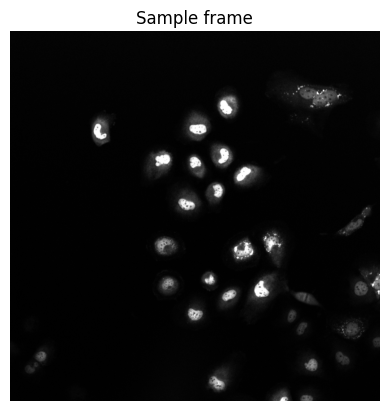

In [ ]:
# Load some images
images = sorted(glob.glob("data/Fluo-C2DL-Huh7_train/Fluo-C2DL-Huh7/01/*.tif"))


img = tiff.imread(images[0])

plt.imshow(img, cmap='gray')
plt.title("Sample frame")
plt.axis('off')

In [ ]:
print("Image size: ", img.shape)
print("Image type: ", img.dtype)

Image size:  (1024, 1024)
Image type:  uint8


Text(0.5, 1.0, 'Rotate')

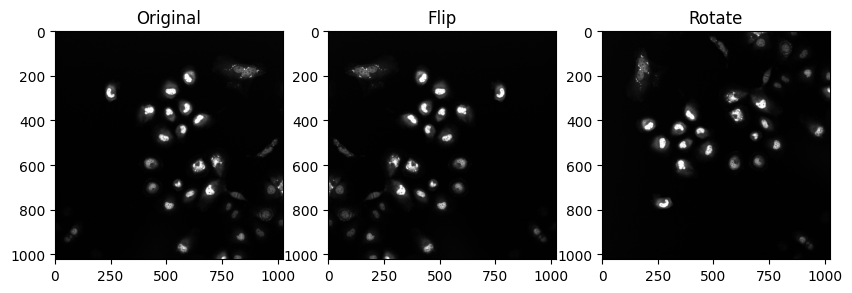

In [ ]:
# Flip
flipped = np.fliplr(img)

# Rotate
rotated = np.rot90(img)

# Show
fig, axs = plt.subplots(1,3, figsize=(10,3))
axs[0].imshow(img, cmap='gray'); axs[0].set_title("Original")
axs[1].imshow(flipped, cmap='gray'); axs[1].set_title("Flip")
axs[2].imshow(rotated, cmap='gray'); axs[2].set_title("Rotate")

Try a random image!

Found 16129 raw image frames across 20 datasets.
Seed: 123
Dataset container: BF-C2DL-HSC_test
Dataset name: BF-C2DL-HSC
Sequence: 01
Frame: t0857.tif
Shape: (1010, 1010)
Dtype: uint8
Min: 45
Max: 231
Mean: 132.28
Std: 9.13


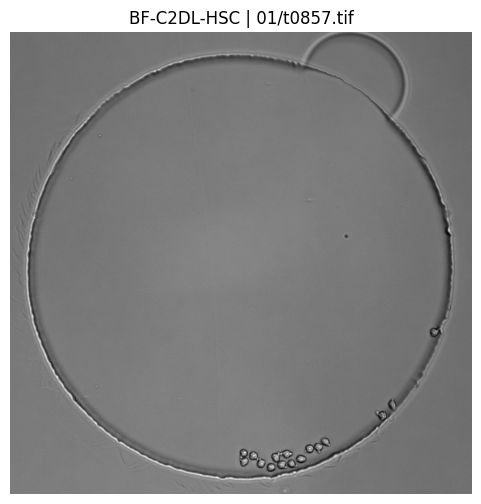

In [ ]:
SEED = 123
show_random_image(seed=SEED)

## Load and Visualize 16 bit Images

The CTC ground-truth annotations are stored as labeled 16-bit TIFF masks rather than display-ready images. As a result, they may appear visually black in standard viewers unless intensity is rescaled or a categorical colormap is applied. In real datasets, tracking annotations provide dense temporal instance coverage, whereas segmentation annotations are sparse but spatially more precise.

shape: (1024, 1024)
dtype: uint16
min: 0 max: 37
unique labels (first 20): [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19]
num unique labels: 32


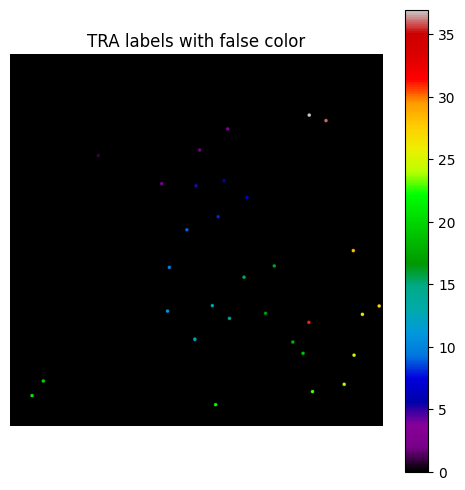

In [ ]:
import tifffile as tiff
import numpy as np
import matplotlib.pyplot as plt

path = "data/Fluo-C2DL-Huh7_train/Fluo-C2DL-Huh7/01_GT/TRA/man_track000.tif"
img = tiff.imread(path)

print("shape:", img.shape)
print("dtype:", img.dtype)
print("min:", img.min(), "max:", img.max())
print("unique labels (first 20):", np.unique(img)[:20])
print("num unique labels:", len(np.unique(img)))

plt.figure(figsize=(6,6))
plt.imshow(img, cmap="nipy_spectral")
plt.colorbar()
plt.title("TRA labels with false color")
plt.axis("off")
plt.show()

shape: (1024, 1024)
dtype: uint16
min: 0 max: 31
unique labels (first 20): [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19]


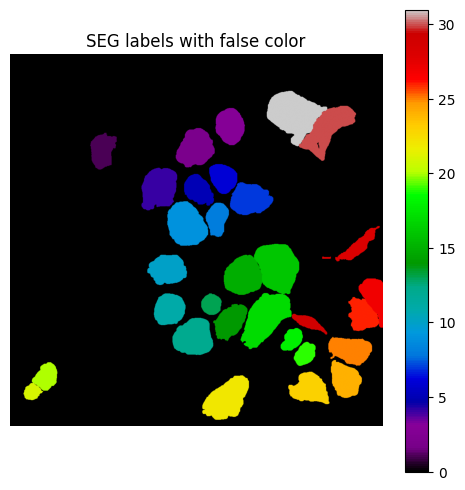

In [ ]:
path = "data/Fluo-C2DL-Huh7_train/Fluo-C2DL-Huh7/01_GT/SEG/man_seg000.tif"
img = tiff.imread(path)

print("shape:", img.shape)
print("dtype:", img.dtype)
print("min:", img.min(), "max:", img.max())
print("unique labels (first 20):", np.unique(img)[:20])

plt.figure(figsize=(6,6))
plt.imshow(img, cmap="nipy_spectral")
plt.colorbar()
plt.title("SEG labels with false color")
plt.axis("off")
plt.show()

## Check Imbalance Dataset

Dataset Overview:
Dataset
BF-C2DL-HSC        7056
BF-C2DL-MuSC       5504
DIC-C2DH-HeLa       398
Fluo-C2DL-Huh7      120
Fluo-C2DL-MSC       192
Fluo-N2DH-GOWT1     368
Fluo-N2DH-SIM+      463
Fluo-N2DL-HeLa      368
PhC-C2DH-U373       460
PhC-C2DL-PSC       1200
Name: Frame_Count, dtype: int64


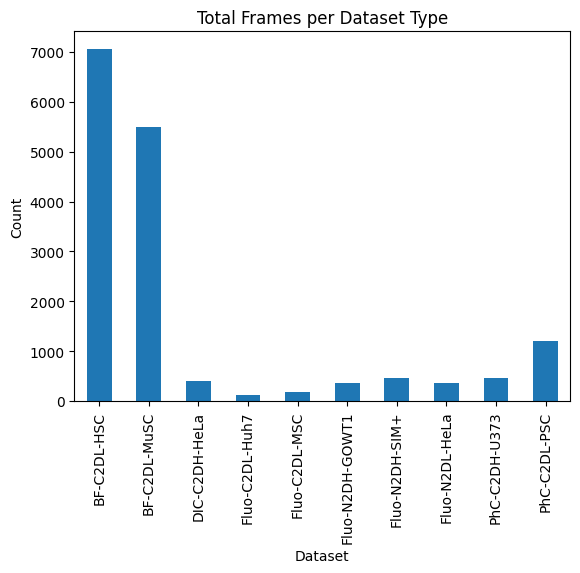

In [ ]:
# --- Continuing from Cell 8 ---
import pandas as pd

def get_dataset_stats(base_dir="data"):
    stats = []
    for root, dirs, files in os.walk(base_dir):
        # Focus on raw image folders (typically '01' or '02')
        if any(f.endswith('.tif') for f in files) and not any(x in root for x in ["_GT", "SEG", "TRA"]):
            tif_files = [f for f in files if f.endswith('.tif')]
            stats.append({
                "Dataset": os.path.basename(os.path.dirname(root)),
                "Sequence": os.path.basename(root),
                "Frame_Count": len(tif_files),
                "Path": root
            })
    return pd.DataFrame(stats)

df_stats = get_dataset_stats()
print("Dataset Overview:")
print(df_stats.groupby("Dataset")["Frame_Count"].sum())

# Visualizing class (dataset) distribution
df_stats.groupby("Dataset")["Frame_Count"].sum().plot(kind='bar', title="Total Frames per Dataset Type")
plt.ylabel("Count")
plt.show()

# Pipeline
Approach:
YOLO + SAM

In [ ]:
!wget https://dl.fbaipublicfiles.com/segment_anything/sam_vit_b_01ec64.pth

--2026-03-18 22:54:57--  https://dl.fbaipublicfiles.com/segment_anything/sam_vit_b_01ec64.pth
Resolving dl.fbaipublicfiles.com (dl.fbaipublicfiles.com)... 18.155.173.79, 18.155.173.40, 18.155.173.80, ...
Connecting to dl.fbaipublicfiles.com (dl.fbaipublicfiles.com)|18.155.173.79|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 375042383 (358M) [binary/octet-stream]
Saving to: ‘sam_vit_b_01ec64.pth’

sam_vit_b_01ec64.pt 100%[===================>] 357.67M   220MB/s    in 1.6s    

2026-03-18 22:54:59 (220 MB/s) - ‘sam_vit_b_01ec64.pth’ saved [375042383/375042383]



In [ ]:
!pip install numpy segment_anything ultralytics opencv-python
!pip install torch torchvision --extra-index-url https://download.pytorch.org/whl/cu113

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 34.0 MB/s eta 0:00:00
Looking in indexes: https://pypi.org/simple, https://download.pytorch.org/whl/cu113


In [ ]:
###### Verifying that CUDA is available. This is mostly to accelerate development.

import torch

# Check if CUDA is available
cuda_available = torch.cuda.is_available()
print(f"CUDA available: {cuda_available}")

if cuda_available:
    # Get the CUDA device name
    device_name = torch.cuda.get_device_name(0)
    print(f"CUDA device name: {device_name}")

CUDA available: True
CUDA device name: Tesla T4


## Testing on 1 image

Detected 31 centroid prompts


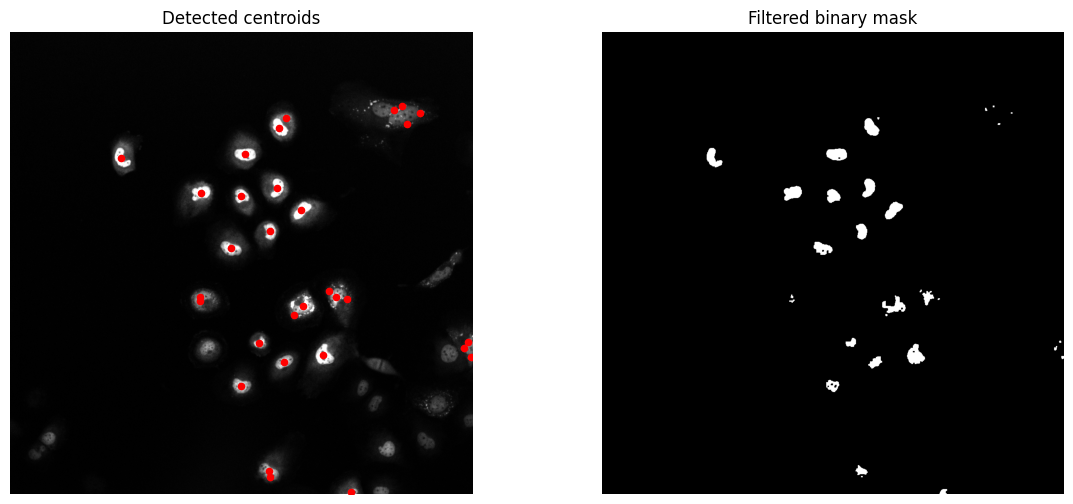

Generated 31 SAM masks


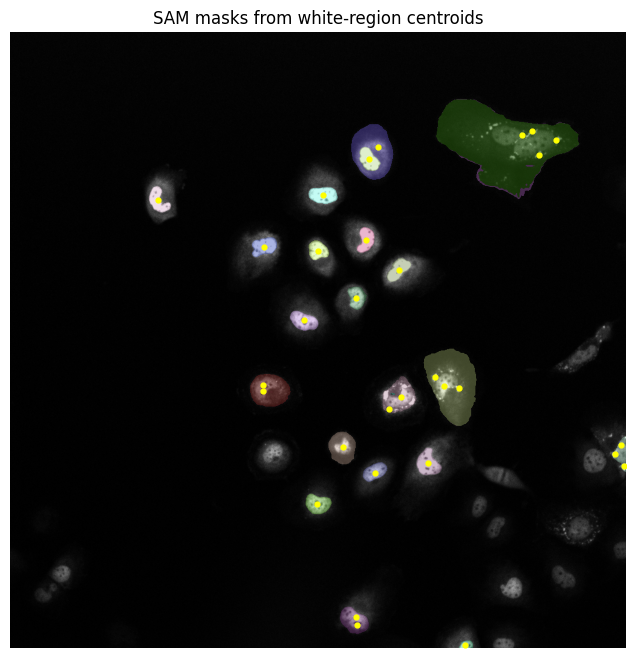

In [ ]:
import glob
import cv2
import tifffile as tiff
import numpy as np
import matplotlib.pyplot as plt
import torch

from segment_anything import sam_model_registry, SamPredictor

images = sorted(glob.glob("data/Fluo-C2DL-Huh7_train/Fluo-C2DL-Huh7/01/*.tif"))
img = tiff.imread(images[0])  # grayscale

# Normalize to uint8 for thresholding / SAM
img_norm = (img - img.min()) / (img.max() - img.min() + 1e-8)
img_uint8 = (img_norm * 255).astype(np.uint8)

# SAM expects 3-channel RGB
img_rgb = np.stack([img_uint8] * 3, axis=-1)

# Create a binary mask of bright cells
# Masking with threshold
_, mask = cv2.threshold(img_uint8, thresh=150, maxval=255, type=cv2.THRESH_BINARY)
binary = cv2.bitwise_and(img_uint8, mask)

# Clean noise with morphology
kernel = np.ones((3, 3), np.uint8)
binary = cv2.morphologyEx(binary, cv2.MORPH_OPEN, kernel, iterations=1)
binary = cv2.morphologyEx(binary, cv2.MORPH_CLOSE, kernel, iterations=1)

# Remove tiny components
num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(binary, connectivity=8)

min_area = 10
filtered_mask = np.zeros_like(binary)
prompt_points = []

for i in range(1, num_labels):  # skip background
    area = stats[i, cv2.CC_STAT_AREA]
    if area >= min_area:
        filtered_mask[labels == i] = 255
        cx, cy = centroids[i]
        prompt_points.append([cx, cy])

prompt_points = np.array(prompt_points, dtype=np.float32)

print(f"Detected {len(prompt_points)} centroid prompts")

# Visualize threshold + centroids
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.imshow(img_uint8, cmap="gray")
if len(prompt_points) > 0:
    plt.scatter(prompt_points[:, 0], prompt_points[:, 1], c="red", s=20)
plt.title("Detected centroids")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(filtered_mask, cmap="gray")
plt.title("Filtered binary mask")
plt.axis("off")

plt.show()

MODEL_TYPE = "vit_b"
CHECKPOINT = "sam_vit_b_01ec64.pth"

device = "cuda" if torch.cuda.is_available() else "cpu"

sam = sam_model_registry[MODEL_TYPE](checkpoint=CHECKPOINT)
sam.to(device=device)

predictor = SamPredictor(sam)
predictor.set_image(img_rgb)

all_masks = []
all_scores = []

for pt in prompt_points:
    point_coords = np.array([pt], dtype=np.float32)
    point_labels = np.array([1], dtype=np.int32)

    masks, scores, _ = predictor.predict(
        point_coords=point_coords,
        point_labels=point_labels,
        multimask_output=True
    )

    best_idx = np.argmax(scores)
    best_mask = masks[best_idx]

    all_masks.append(best_mask)
    all_scores.append(scores[best_idx])

print(f"Generated {len(all_masks)} SAM masks")


label_map = np.zeros(img_uint8.shape, dtype=np.int32)

for idx, mask in enumerate(all_masks, start=1):
    label_map[mask] = idx


plt.figure(figsize=(8, 8))
plt.imshow(img_uint8, cmap="gray")

# overlay masks
overlay = np.zeros((img_uint8.shape[0], img_uint8.shape[1], 4), dtype=np.float32)
rng = np.random.default_rng(42)

for idx, mask in enumerate(all_masks):
    color = rng.random(3)
    overlay[mask, :3] = color
    overlay[mask, 3] = 0.35

plt.imshow(overlay)

if len(prompt_points) > 0:
    plt.scatter(prompt_points[:, 0], prompt_points[:, 1], c="yellow", s=12)

plt.title("SAM masks from white-region centroids")
plt.axis("off")
plt.show()

## Detect Cell Helper Function

In [ ]:
def detect_cells(image_path, predictor):
    img = tiff.imread(image_path)

    img_norm = (img - img.min()) / (img.max() - img.min() + 1e-8)
    img_uint8 = (img_norm * 255).astype(np.uint8)
    img_rgb = np.stack([img_uint8] * 3, axis=-1)

    predictor.set_image(img_rgb)

    # ---- threshold ----
    _, mask = cv2.threshold(img_uint8, 150, 255, cv2.THRESH_BINARY)
    binary = cv2.bitwise_and(img_uint8, mask)

    kernel = np.ones((3, 3), np.uint8)
    binary = cv2.morphologyEx(binary, cv2.MORPH_OPEN, kernel)
    binary = cv2.morphologyEx(binary, cv2.MORPH_CLOSE, kernel)

    num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(binary, 8)

    min_area = 10
    prompt_points = []

    for i in range(1, num_labels):
        if stats[i, cv2.CC_STAT_AREA] >= min_area:
            cx, cy = centroids[i]
            prompt_points.append([cx, cy])

    prompt_points = np.array(prompt_points, dtype=np.float32)

    # ---- SAM masks ----
    masks_out = []
    centroids_out = []

    for pt in prompt_points:
        masks, scores, _ = predictor.predict(
            point_coords=np.array([pt]),
            point_labels=np.array([1]),
            multimask_output=True
        )

        best = masks[np.argmax(scores)]
        masks_out.append(best)
        centroids_out.append(pt)

    return np.array(centroids_out), masks_out

In [ ]:
def match_cells(prev_centroids, curr_centroids, max_dist=30):
    matches = {}
    used = set()

    for i, p in enumerate(prev_centroids):
        dists = np.linalg.norm(curr_centroids - p, axis=1)

        j = np.argmin(dists)
        if dists[j] < max_dist and j not i  n used:
            matches[i] = j
            used.add(j)

    return matches

## Testing on image series

In [ ]:
import glob
import cv2
import tifffile as tiff
import numpy as np
import matplotlib.pyplot as plt
import torch

from segment_anything import sam_model_registry, SamPredictor

# -----------------------------
# Load one microscopy image
# -----------------------------
images = sorted(glob.glob("data/Fluo-C2DL-Huh7_train/Fluo-C2DL-Huh7/01/*.tif"))

for image in images:
  img = tiff.imread(image)  # grayscale

  # Normalize to uint8 for thresholding / SAM
  img_norm = (img - img.min()) / (img.max() - img.min() + 1e-8)
  img_uint8 = (img_norm * 255).astype(np.uint8)

  # SAM expects 3-channel RGB
  img_rgb = np.stack([img_uint8] * 3, axis=-1)



In [ ]:
tracks = {}
next_id = 0

prev_centroids, prev_masks = detect_cells(images[0], predictor)

# initialize tracks
for i, c in enumerate(prev_centroids):
    tracks[next_id] = [c]
    next_id += 1

# loop over frames
for t in range(1, len(images)):
    curr_centroids, curr_masks = detect_cells(images[t], predictor)

    matches = match_cells(prev_centroids, curr_centroids)

    new_tracks = {}

    # matched
    for prev_idx, curr_idx in matches.items():
        track_id = list(tracks.keys())[prev_idx]
        new_tracks[track_id] = tracks[track_id] + [curr_centroids[curr_idx]]

    # unmatched → new cells
    matched_curr = set(matches.values())

    for i, c in enumerate(curr_centroids):
        if i not in matched_curr:
            new_tracks[next_id] = [c]
            next_id += 1

    tracks = new_tracks
    prev_centroids = curr_centroids

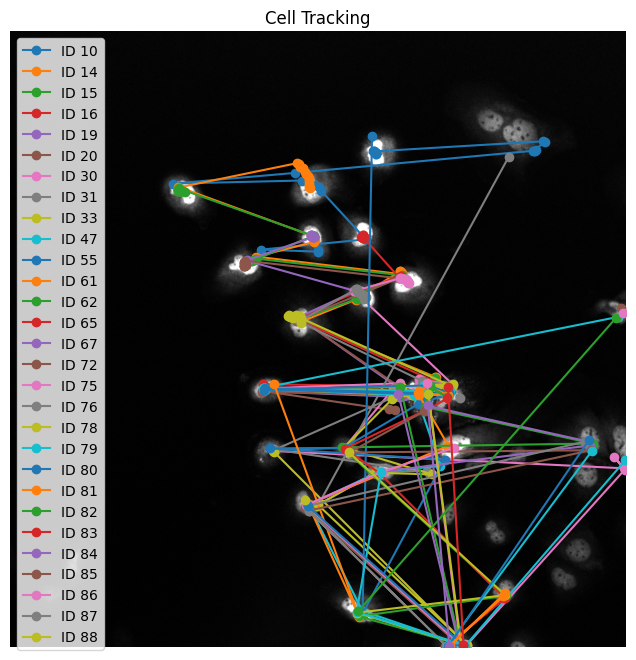

In [ ]:
plt.figure(figsize=(8, 8))

img = tiff.imread(images[-1])
plt.imshow(img, cmap="gray")

for track_id, points in tracks.items():
    pts = np.array(points)
    plt.plot(pts[:, 0], pts[:, 1], '-o', label=f'ID {track_id}')

plt.legend()
plt.title("Cell Tracking")
plt.axis("off")
plt.show()

# Image Detection Evaluation

In [ ]:
# Load corresponding ground truth mask
gt_paths = sorted(glob.glob("data/Fluo-C2DL-Huh7_test/Fluo-C2DL-Huh7/01/*.tif"))

gt = tiff.imread(gt_paths[0])

# Convert GT to binary (cells vs background)
gt_binary = (gt > 0).astype(np.uint8)
pred_binary = (label_map > 0).astype(np.uint8)

In [ ]:
def compute_iou(pred, gt):
    intersection = np.logical_and(pred, gt).sum()
    union = np.logical_or(pred, gt).sum()
    return intersection / (union + 1e-8)

def compute_dice(pred, gt):
    intersection = np.logical_and(pred, gt).sum()
    return (2 * intersection) / (pred.sum() + gt.sum() + 1e-8)

import numpy as np

def compute_seg_from_masks(gt_masks, pred_masks, iou_threshold=0.5):
    """
    Compute SEG metric (CTC-style) using precomputed IoU function.

    Args:
        gt_masks: list of (H, W) binary numpy arrays (ground truth instances)
        pred_masks: list of (H, W) binary numpy arrays (predicted instances)
        iou_threshold: float (default = 0.5)

    Returns:
        SEG score (float)
    """

    if len(gt_masks) == 0:
        return 1.0  # edge case: no GT objects

    seg_scores = []
    used_preds = set()

    for gt in gt_masks:
        best_iou = 0
        best_j = -1

        for j, pred in enumerate(pred_masks):
            if j in used_preds:
                continue

            iou = compute_iou(gt, pred)

            if iou > best_iou:
                best_iou = iou
                best_j = j

        # Apply CTC rule
        if best_iou > iou_threshold:
            seg_scores.append(best_iou)
            used_preds.add(best_j)
        else:
            seg_scores.append(0.0)

    return float(np.mean(seg_scores))

## Single Image test

In [ ]:
iou = compute_iou(pred_binary, gt_binary)
dice = compute_dice(pred_binary, gt_binary)

print(f"IoU: {iou:.4f}")
print(f"Dice: {dice:.4f}")

IoU: 0.0432
Dice: 0.0828


## Evaluating the Cell Detection on Fluo-C2D:-Huh7

In [ ]:
image_paths = sorted(glob.glob("data/Fluo-C2DL-Huh7_test/Fluo-C2DL-Huh7/01/*.tif"))
gt_paths = sorted(glob.glob("data/Fluo-C2DL-Huh7_test/Fluo-C2DL-Huh7/01/*.tif"))

ious = []
dices = []

for img_path, gt_path in zip(image_paths, gt_paths):
    img = tiff.imread(img_path)

    # --- your preprocessing ---
    img_norm = (img - img.min()) / (img.max() - img.min() + 1e-8)
    img_uint8 = (img_norm * 255).astype(np.uint8)
    img_rgb = np.stack([img_uint8] * 3, axis=-1)

    # --- thresholding ---
    _, mask = cv2.threshold(img_uint8, 150, 255, cv2.THRESH_BINARY)
    binary = cv2.bitwise_and(img_uint8, mask)

    kernel = np.ones((3, 3), np.uint8)
    binary = cv2.morphologyEx(binary, cv2.MORPH_OPEN, kernel)
    binary = cv2.morphologyEx(binary, cv2.MORPH_CLOSE, kernel)

    num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(binary, 8)

    prompt_points = []
    for i in range(1, num_labels):
        if stats[i, cv2.CC_STAT_AREA] >= 10:
            cx, cy = centroids[i]
            prompt_points.append([cx, cy])

    prompt_points = np.array(prompt_points, dtype=np.float32)

    # --- SAM inference ---
    predictor.set_image(img_rgb)

    all_masks = []
    for pt in prompt_points:
        masks, scores, _ = predictor.predict(
            point_coords=np.array([pt]),
            point_labels=np.array([1]),
            multimask_output=True
        )
        best_mask = masks[np.argmax(scores)]
        all_masks.append(best_mask)

    label_map = np.zeros(img_uint8.shape, dtype=np.uint8)
    for mask in all_masks:
        label_map[mask] = 1

    # --- load GT ---
    gt = tiff.imread(gt_path)
    gt_binary = (gt > 0).astype(np.uint8)

    # --- metrics ---
    ious.append(compute_iou(label_map, gt_binary))
    dices.append(compute_dice(label_map, gt_binary))

In [ ]:
print("==== FINAL RESULTS ====")
print(f"Mean IoU:  {np.mean(ious):.4f}")
print(f"Mean Dice: {np.mean(dices):.4f}")

==== FINAL RESULTS ====
Mean IoU:  0.0475
Mean Dice: 0.0904


## Evaluation on Tracking

In [ ]:
def extract_gt_tracks(tra_path):
    gt = tiff.imread(tra_path)  # shape: (T, H, W)

    tracks = {}

    for t in range(gt.shape[0]):
        labels = np.unique(gt[t])
        labels = labels[labels != 0]  # remove background

        for lab in labels:
            ys, xs = np.where(gt[t] == lab)

            cx = xs.mean()
            cy = ys.mean()

            if lab not in tracks:
                tracks[lab] = []

            tracks[lab].append((t, cx, cy))

    return tracks

In [ ]:
def format_pred_tracks(tracks):
    formatted = {}

    for tid, points in tracks.items():
        formatted[tid] = []
        for t, (x, y) in enumerate(points):
            formatted[tid].append((t, x, y))

    return formatted

In [ ]:
def track_distance(gt_track, pred_track):
    dist = 0
    count = 0

    for (t1, x1, y1), (t2, x2, y2) in zip(gt_track, pred_track):
        if t1 == t2:
            dist += np.sqrt((x1 - x2)**2 + (y1 - y2)**2)
            count += 1

    return dist / (count + 1e-6)

In [ ]:
def evaluate_tracking(gt_tracks, pred_tracks, max_dist=30):
    matched = 0
    total_gt = len(gt_tracks)

    used_pred = set()

    for gt_id, gt_track in gt_tracks.items():
        best_match = None
        best_dist = float("inf")

        for pred_id, pred_track in pred_tracks.items():
            if pred_id in used_pred:
                continue

            d = track_distance(gt_track, pred_track)

            if d < best_dist:
                best_dist = d
                best_match = pred_id

        if best_dist < max_dist:
            matched += 1
            used_pred.add(best_match)

    precision = matched / (len(pred_tracks) + 1e-6)
    recall = matched / (total_gt + 1e-6)

    f1 = 2 * precision * recall / (precision + recall + 1e-6)

    return precision, recall, f1

In [ ]:
path = "data/Fluo-C2DL-Huh7_train/Fluo-C2DL-Huh7/01_GT/TRA/*.tif"

gt_tracks = extract_gt_tracks(path)
pred_tracks = format_pred_tracks(tracks)

precision, recall, f1 = evaluate_tracking(gt_tracks, pred_tracks)

print("==== TRACKING RESULTS ====")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1 Score:  {f1:.4f}")

==== TRACKING RESULTS ====
Precision: 0.1379
Recall:    0.1176
F1 Score:  0.1270


#EXPERIMENT 1

In [ ]:
def mask_iou(m1, m2):
    m1 = m1.astype(bool)
    m2 = m2.astype(bool)

    inter = np.logical_and(m1, m2).sum()
    union = np.logical_or(m1, m2).sum()

    return inter / (union + 1e-6)

In [ ]:
def match_cells_iou(prev_centroids, prev_masks,
                    curr_centroids, curr_masks,
                    max_dist=30, min_iou=0.1):

    matches = {}
    used = set()

    for i, (p_cent, p_mask) in enumerate(zip(prev_centroids, prev_masks)):

        best_j = -1
        best_score = -1

        for j, (c_cent, c_mask) in enumerate(zip(curr_centroids, curr_masks)):
            if j in used:
                continue

            # distance
            dist = np.linalg.norm(p_cent - c_cent)
            if dist > max_dist:
                continue

            # IoU
            iou = mask_iou(p_mask, c_mask)

            # combined score (you can tune this)
            score = iou - 0.01 * dist

            if score > best_score:
                best_score = score
                best_j = j

        if best_j != -1:
            matches[i] = best_j
            used.add(best_j)

    return matches

In [ ]:
tracks = {}
next_id = 0

prev_centroids, prev_masks = detect_cells(images[0], predictor)

# initialize tracks
for i, c in enumerate(prev_centroids):
    tracks[next_id] = [c]
    next_id += 1

# loop over frames
for t in range(1, len(images)):
    curr_centroids, curr_masks = detect_cells(images[t], predictor)

    matches = match_cells_iou(
        prev_centroids, prev_masks,
        curr_centroids, curr_masks
    )

    new_tracks = {}

    # matched
    for prev_idx, curr_idx in matches.items():
        track_id = list(tracks.keys())[prev_idx]
        new_tracks[track_id] = tracks[track_id] + [curr_centroids[curr_idx]]

    # unmatched → new cells
    matched_curr = set(matches.values())

    for i, c in enumerate(curr_centroids):
        if i not in matched_curr:
            new_tracks[next_id] = [c]
            next_id += 1

    tracks = new_tracks
    prev_centroids = curr_centroids

In [ ]:
path = "data/Fluo-C2DL-Huh7_train/Fluo-C2DL-Huh7/01_GT/TRA/*.tif"

gt_tracks = extract_gt_tracks(path)
pred_tracks = format_pred_tracks(tracks)

precision, recall, f1 = evaluate_tracking(gt_tracks, pred_tracks)

print("==== TRACKING RESULTS ====")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1 Score:  {f1:.4f}")

==== TRACKING RESULTS ====
Precision: 0.1379
Recall:    0.1176
F1 Score:  0.1270


Result is the same meaning there's a problem with the IoU

In [ ]:
for i, (p_mask) in enumerate(prev_masks):
    for j, (c_mask) in enumerate(curr_masks):
        iou = mask_iou(p_mask, c_mask)
        if iou > 0:
            print(f"prev {i} -> curr {j}: IoU = {iou:.4f}")

prev 3 -> curr 0: IoU = 0.1921
prev 4 -> curr 0: IoU = 0.2490
prev 7 -> curr 1: IoU = 0.2145
prev 8 -> curr 3: IoU = 0.4424
prev 10 -> curr 4: IoU = 0.0870
prev 12 -> curr 7: IoU = 0.2758
prev 13 -> curr 9: IoU = 0.4390
prev 14 -> curr 13: IoU = 0.0024
prev 14 -> curr 14: IoU = 0.3482
prev 14 -> curr 15: IoU = 0.1443
prev 14 -> curr 16: IoU = 0.1449
prev 14 -> curr 17: IoU = 0.3475
prev 14 -> curr 18: IoU = 0.0034
prev 15 -> curr 13: IoU = 0.0025
prev 15 -> curr 14: IoU = 0.3521
prev 15 -> curr 15: IoU = 0.1510
prev 15 -> curr 16: IoU = 0.1516
prev 15 -> curr 17: IoU = 0.3515
prev 15 -> curr 18: IoU = 0.0035
prev 16 -> curr 12: IoU = 0.7465
prev 17 -> curr 13: IoU = 0.1113
prev 17 -> curr 14: IoU = 0.0527
prev 17 -> curr 17: IoU = 0.0556
prev 17 -> curr 18: IoU = 0.1059
prev 18 -> curr 13: IoU = 0.0040
prev 18 -> curr 14: IoU = 0.3545
prev 18 -> curr 15: IoU = 0.1377
prev 18 -> curr 16: IoU = 0.1381
prev 18 -> curr 17: IoU = 0.3538
prev 18 -> curr 18: IoU = 0.0049
prev 19 -> curr 12: I

# SEG


In [ ]:
import numpy as np
import tifffile as tiff
import cv2
import glob
from scipy import ndimage

def compute_seg_metric(pred_label_map, gt_label_map):
    """
    Compute the SEG metric as defined in the Cell Tracking Challenge.
    
    SEG = mean over all GT objects of: 
          Jaccard(gt_i, best_matching_pred_j)  if max Jaccard >= 0.5, else 0
    
    Args:
        pred_label_map: 2D numpy array, integer-labeled predicted segmentation
                        (0 = background, 1..N = cell instances)
        gt_label_map:   2D numpy array, integer-labeled GT segmentation
                        (0 = background, 1..M = cell instances)
    
    Returns:
        seg_score: float in [0, 1]
        n_gt:      number of GT objects (denominator)
        n_matched: number of GT objects with a match (Jaccard >= 0.5)
    """
    gt_ids = np.unique(gt_label_map)
    gt_ids = gt_ids[gt_ids != 0]  # exclude background

    if len(gt_ids) == 0:
        return 1.0, 0, 0  # no GT objects → perfect by convention

    jaccard_scores = []

    for gt_id in gt_ids:
        gt_mask = (gt_label_map == gt_id)

        # Find all predicted labels that overlap with this GT object
        overlapping_pred_ids = np.unique(pred_label_map[gt_mask])
        overlapping_pred_ids = overlapping_pred_ids[overlapping_pred_ids != 0]

        best_jaccard = 0.0

        for pred_id in overlapping_pred_ids:
            pred_mask = (pred_label_map == pred_id)

            intersection = np.logical_and(gt_mask, pred_mask).sum()
            union = np.logical_or(gt_mask, pred_mask).sum()
            jaccard = intersection / union if union > 0 else 0.0

            if jaccard > best_jaccard:
                best_jaccard = jaccard

        # CTC rule: only count if best match clears the 0.5 threshold
        jaccard_scores.append(best_jaccard if best_jaccard >= 0.5 else 0.0)

    seg_score = np.mean(jaccard_scores)
    n_matched = sum(j > 0 for j in jaccard_scores)

    return seg_score, len(gt_ids), n_matched


def labels_from_binary_masks(all_masks, shape):
    """
    Convert a list of binary masks into an integer label map.
    Later masks overwrite earlier ones where they overlap (simple approach).
    """
    label_map = np.zeros(shape, dtype=np.int32)
    for idx, mask in enumerate(all_masks, start=1):
        label_map[mask] = idx
    return label_map

In [ ]:
seg_scores = []

for img_path, gt_path in zip(image_paths, gt_paths):
    img = tiff.imread(img_path)

    # --- your preprocessing (unchanged) ---
    img_norm = (img - img.min()) / (img.max() - img.min() + 1e-8)
    img_uint8 = (img_norm * 255).astype(np.uint8)
    img_rgb = np.stack([img_uint8] * 3, axis=-1)

    _, mask = cv2.threshold(img_uint8, 150, 255, cv2.THRESH_BINARY)
    binary = cv2.bitwise_and(img_uint8, mask)
    kernel = np.ones((3, 3), np.uint8)
    binary = cv2.morphologyEx(binary, cv2.MORPH_OPEN, kernel)
    binary = cv2.morphologyEx(binary, cv2.MORPH_CLOSE, kernel)

    num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(binary, 8)
    prompt_points = []
    for i in range(1, num_labels):
        if stats[i, cv2.CC_STAT_AREA] >= 10:
            cx, cy = centroids[i]
            prompt_points.append([cx, cy])
    prompt_points = np.array(prompt_points, dtype=np.float32)

    # --- SAM inference (unchanged) ---
    predictor.set_image(img_rgb)
    all_masks = []
    for pt in prompt_points:
        masks, scores, _ = predictor.predict(
            point_coords=np.array([pt]),
            point_labels=np.array([1]),
            multimask_output=True
        )
        best_mask = masks[np.argmax(scores)]
        all_masks.append(best_mask)

    # --- Build INSTANCE label map (not binary!) ---
    pred_label_map = labels_from_binary_masks(all_masks, img_uint8.shape)

    # --- Load GT as instance label map ---
    gt_label_map = tiff.imread(gt_path).astype(np.int32)  # CTC GT is already instance-labeled

    # --- SEG metric ---
    seg, n_gt, n_matched = compute_seg_metric(pred_label_map, gt_label_map)
    seg_scores.append(seg)
    print(f"{img_path} | SEG={seg:.4f} | GT cells={n_gt} | matched={n_matched}")

print(f"\nMean SEG: {np.mean(seg_scores):.4f}")